# Multinomial Logistic Regression Error Analysis

## Brain Connectivity Classification: Limitations and the Case for Alternative Approaches

This notebook analyzes the error patterns of multinomial logistic regression applied to brain region classification using functional connectivity fingerprints (232 regions). The analysis reveals fundamental limitations of the multinomial approach that motivate the use of **One-vs-Rest (OvR)** and **One-vs-One (OvO)** strategies.

### Key Research Questions
1. How does multinomial classification perform across 232 brain regions?
2. What error patterns emerge in rest vs. task conditions?
3. What are the structural limitations of multinomial for high-dimensional multi-class problems?

### Notebook Structure
1. **Setup & Data Loading** - Environment configuration and data import
2. **Model Performance Overview** - Cross-validation and task transfer accuracy
3. **Network-Level Error Analysis** - Error distribution across functional networks
4. **Hemisphere Confusion Analysis** - Within vs. cross-hemisphere errors
5. **Confusion Flow Visualization** - Sankey diagrams of error pathways
6. **Regional Error Patterns** - Fine-grained error analysis
7. **Limitations Summary** - Evidence for OvR/OvO approaches

---
## 1. Setup & Data Loading

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import json
from pathlib import Path
import warnings

# Statistical Analysis
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Path Configuration
PROJECT_ROOT = Path('/home/sjoon/projects/brain_connectivity_classifier')
RESULTS_DIR = PROJECT_ROOT / 'data' / 'results'

# Directory Setup for Each Model
full_multi_dir = RESULTS_DIR / 'full_connectivity_analysis' / 'multinomial'
LH_multi_dir = RESULTS_DIR / 'hemisphere_analysis' / 'left_hemisphere' / 'multinomial'
RH_multi_dir = RESULTS_DIR / 'hemisphere_analysis' / 'right_hemisphere' / 'multinomial'

full_task_dir = RESULTS_DIR / 'full_connectivity_analysis' / 'task_testing'
LH_task_dir = RESULTS_DIR / 'hemisphere_analysis' / 'left_hemisphere' / 'task_testing_multinomial'
RH_task_dir = RESULTS_DIR / 'hemisphere_analysis' / 'right_hemisphere' / 'task_testing_multinomial'

print(f"Results Directory: {RESULTS_DIR}")

Results Directory: /home/sjoon/projects/brain_connectivity_classifier/data/results


In [3]:
# Helper Functions
def load_json(filepath):
    """Load JSON file safely"""
    with open(filepath, 'r') as f:
        return json.load(f)

def load_npy(filepath):
    """Load numpy file safely"""
    return np.load(filepath, allow_pickle=True)

def load_csv(filepath):
    """Load CSV file safely"""
    return pd.read_csv(filepath)

def load_bundle(m_dir, t_dir):
    """Load standard file patterns from directories."""
    return [
        load_json(m_dir / 'overall_metrics.json'), 
        load_json(m_dir / 'fold_metrics.json'),
        load_csv(m_dir / 'network_metrics.csv'), 
        load_csv(m_dir / 'per_region_metrics.csv'),
        load_npy(m_dir / 'confusion_matrix.npy'), 
        load_npy(m_dir / 'cv_predictions.npy'),
        load_npy(m_dir / 'cv_probabilities.npy'), 
        load_npy(m_dir / 'cv_true_labels.npy'),
        load_npy(m_dir / 'cv_fold_indices.npy'), 
        load_json(t_dir / 'task_testing_summary.json'),
        load_csv(t_dir / 'task_network_metrics.csv'), 
        load_csv(t_dir / 'task_per_region_metrics.csv'),
        load_npy(t_dir / 'task_confusion_matrix.npy'), 
        load_npy(t_dir / 'task_predictions.npy'),
        load_npy(t_dir / 'task_probabilities.npy'), 
        load_npy(t_dir / 'task_true_labels.npy')
    ]

print("✓ Helper functions loaded")

✓ Helper functions loaded


In [4]:
# Load All Data

# Full Connectivity Model (232 regions)
overall_metrics_full, fold_metrics_full, network_metrics_cv_full, per_region_metrics_cv_full, \
confusion_matrix_cv_full, cv_predictions_full, cv_probabilities_full, cv_true_labels_full, \
cv_fold_indices_full, task_summary_full, network_metrics_task_full, per_region_metrics_task_full, \
confusion_matrix_task_full, task_predictions_full, task_probabilities_full, task_true_labels_full = load_bundle(full_multi_dir, full_task_dir)

region_info_full = load_csv(full_multi_dir / 'region_info.csv')

# Left Hemisphere Model (116 regions)
overall_metrics_lh, fold_metrics_lh, network_metrics_cv_lh, per_region_metrics_cv_lh, \
confusion_matrix_cv_lh, cv_predictions_lh, cv_probabilities_lh, cv_true_labels_lh, \
cv_fold_indices_lh, task_summary_lh, network_metrics_task_lh, per_region_metrics_task_lh, \
confusion_matrix_task_lh, task_predictions_lh, task_probabilities_lh, task_true_labels_lh = load_bundle(LH_multi_dir, LH_task_dir)

region_info_lh = region_info_full[region_info_full['hemisphere'] == 'left'].copy().assign(region_idx=lambda x: range(len(x)))

# Right Hemisphere Model (116 regions)
overall_metrics_rh, fold_metrics_rh, network_metrics_cv_rh, per_region_metrics_cv_rh, \
confusion_matrix_cv_rh, cv_predictions_rh, cv_probabilities_rh, cv_true_labels_rh, \
cv_fold_indices_rh, task_summary_rh, network_metrics_task_rh, per_region_metrics_task_rh, \
confusion_matrix_task_rh, task_predictions_rh, task_probabilities_rh, task_true_labels_rh = load_bundle(RH_multi_dir, RH_task_dir)

region_info_rh = region_info_full[region_info_full['hemisphere'] == 'right'].copy().assign(region_idx=lambda x: range(len(x)))

print("✓ All data loaded successfully")

✓ All data loaded successfully


---
## 2. Model Performance Overview

We compare three multinomial models to understand baseline performance before analyzing error patterns.

In [5]:
# Model Comparison Summary
models = [
    ('Full (232)', overall_metrics_full, task_summary_full, region_info_full, cv_predictions_full, task_predictions_full, confusion_matrix_cv_full),
    ('Left (116)', overall_metrics_lh, task_summary_lh, region_info_lh, cv_predictions_lh, task_predictions_lh, confusion_matrix_cv_lh),
    ('Right (116)', overall_metrics_rh, task_summary_rh, region_info_rh, cv_predictions_rh, task_predictions_rh, confusion_matrix_cv_rh)
]

comparison_df = pd.DataFrame([{
    'Model': m[0],
    'CV_Accuracy': f"{m[1]['accuracy']:.4f}",
    'Rest_Train_Acc': f"{m[2]['rest_train_accuracy']:.4f}",
    'Task_Accuracy': f"{m[2]['task_test_accuracy']:.4f}",
    'Accuracy_Drop': f"{m[2]['accuracy_drop']:.4f}",
    'N_Regions': len(m[3]),
    'N_Samples_CV': len(m[4]),
    'N_Samples_Task': len(m[5]),
    'CM_Shape': f"{m[6].shape[0]}×{m[6].shape[1]}"
} for m in models])

print("="*80)
print("MULTINOMIAL MODEL COMPARISON")
print("="*80)
print(f"\n{comparison_df.to_string(index=False)}")
print("\n" + "="*80)
print("KEY OBSERVATION: ~9-10% accuracy drop from rest to task across all models")
print("This indicates systematic changes in connectivity patterns during task performance.")
print("="*80)

MULTINOMIAL MODEL COMPARISON

      Model CV_Accuracy Rest_Train_Acc Task_Accuracy Accuracy_Drop  N_Regions  N_Samples_CV  N_Samples_Task CM_Shape
 Full (232)      0.9241         0.9902        0.8924        0.0978        232         51968           46400  232×232
 Left (116)      0.9182         0.9773        0.8693        0.1080        116         25984           23200  116×116
Right (116)      0.9136         0.9774        0.8631        0.1143        116         25984           23200  116×116

KEY OBSERVATION: ~9-10% accuracy drop from rest to task across all models
This indicates systematic changes in connectivity patterns during task performance.


---
## 3. Network Distribution Analysis

Understanding the hierarchical network structure (33 fine-grained networks → 8 major networks) provides context for interpreting error patterns.

In [6]:
# 8-Network Grouping Mapping (Yeo-7 + Subcortical)
network_to_major = {
    'VisCent': 'Visual', 'VisPeri': 'Visual',
    'SomMotA': 'Somatomotor', 'SomMotB': 'Somatomotor',
    'DorsAttnA': 'Dorsal Attention', 'DorsAttnB': 'Dorsal Attention',
    'SalVentAttnA': 'Salience/Ventral Attention', 'SalVentAttnB': 'Salience/Ventral Attention',
    'LimbicA': 'Limbic', 'LimbicB': 'Limbic',
    'ContA': 'Control', 'ContB': 'Control', 'ContC': 'Control',
    'DefaultA': 'Default', 'DefaultB': 'Default', 'DefaultC': 'Default',
    'TempPar': 'Default',
    'Hippocampus_ant': 'Subcortical', 'Hippocampus_post': 'Subcortical',
    'Amygdala_lat': 'Subcortical', 'Amygdala_med': 'Subcortical',
    'Thalamus_DA': 'Subcortical', 'Thalamus_DP': 'Subcortical',
    'Thalamus_VA': 'Subcortical', 'Thalamus_VP': 'Subcortical',
    'Caudate_ant': 'Subcortical', 'Caudate_post': 'Subcortical',
    'Putamen_ant': 'Subcortical', 'Putamen_post': 'Subcortical',
    'Pallidum_ant': 'Subcortical', 'Pallidum_post': 'Subcortical',
    'Accumbens_core': 'Subcortical', 'Accumbens_shell': 'Subcortical'
}

# Apply mapping to all region info DataFrames
for df in [region_info_full, region_info_lh, region_info_rh]:
    df['major_network'] = df['network'].map(network_to_major)

# Display network distribution
print("="*80)
print("MAJOR NETWORK DISTRIBUTION (8 Networks)")
print("="*80)

major_counts = region_info_full.groupby('major_network').size().reset_index(name='Full_Model')
major_counts['Left_Hemi'] = region_info_lh.groupby('major_network').size().values
major_counts['Right_Hemi'] = region_info_rh.groupby('major_network').size().values
major_counts['% of Total'] = (major_counts['Full_Model'] / 232 * 100).round(1)

print(f"\n{major_counts.to_string(index=False)}")

MAJOR NETWORK DISTRIBUTION (8 Networks)

             major_network  Full_Model  Left_Hemi  Right_Hemi  % of Total
                   Control          37         18          19        15.9
                   Default          43         26          17        18.5
          Dorsal Attention          22         11          11         9.5
                    Limbic          14          6           8         6.0
Salience/Ventral Attention          26         11          15        11.2
               Somatomotor          34         16          18        14.7
               Subcortical          32         16          16        13.8
                    Visual          24         12          12        10.3


---
## 4. Error Source Analysis

This section examines the **types** of classification errors to understand *where* the multinomial model struggles.

### Error Categories:
- **Within-Region**: Same hemisphere AND same network (fine-grained confusion)
- **Network-Only**: Same hemisphere, different network
- **Hemisphere-Only**: Different hemisphere, same network  
- **Both Wrong**: Different hemisphere AND different network

In [7]:
def analyze_errors_comprehensive(true_labels, pred_labels, region_info_df, strategy_name, data_type):
    """Analyze classification errors by hemisphere and network confusion types."""
    err_mask = true_labels != pred_labels
    total_samples, total_err = len(true_labels), err_mask.sum()
    
    fmt = lambda c: f"{c} ({(c / total_err * 100 if total_err > 0 else 0):.1f}%)"

    if total_err == 0:
        return [strategy_name, data_type, 0, "0.00%", "0 (0.0%)", "0 (0.0%)", "0 (0.0%)", "0 (0.0%)"]

    lookup = region_info_df.set_index('region_idx')
    df = pd.DataFrame({'true_idx': true_labels[err_mask], 'pred_idx': pred_labels[err_mask]})
    
    for col, attr in [('true_net', 'network'), ('pred_net', 'network'), 
                      ('true_hemi', 'hemisphere'), ('pred_hemi', 'hemisphere')]:
        df[col] = df['true_idx' if 'true' in col else 'pred_idx'].map(lookup[attr])

    s_h, s_n = (df['true_hemi'] == df['pred_hemi']), (df['true_net'] == df['pred_net'])

    return [
        strategy_name, data_type, total_err, f"{(total_err / total_samples) * 100:.2f}%",
        fmt((s_h & s_n).sum()), fmt((s_h & ~s_n).sum()), fmt((~s_h & s_n).sum()), fmt((~s_h & ~s_n).sum())
    ]

# Configure analyses
configs = [
    (cv_true_labels_full, cv_predictions_full, region_info_full, "Full", "Rest"),
    (task_true_labels_full, task_predictions_full, region_info_full, "Full", "Task"),
    (cv_true_labels_lh, cv_predictions_lh, region_info_lh, "LH_Hemi", "Rest"),
    (task_true_labels_lh, task_predictions_lh, region_info_lh, "LH_Hemi", "Task"),
    (cv_true_labels_rh, cv_predictions_rh, region_info_rh, "RH_Hemi", "Rest"),
    (task_true_labels_rh, task_predictions_rh, region_info_rh, "RH_Hemi", "Task")
]

# Process and display
error_comparison_table = [analyze_errors_comprehensive(*c) for c in configs]
columns = ["Model", "Data", "Total_Err", "Err_Rate", "Within_Reg", "Net_Only", "Hemi_Only", "Both_Wrong"]
error_df = pd.DataFrame(error_comparison_table, columns=columns)

print("="*100)
print("ERROR SOURCE COMPARISON: Multinomial Classification")
print("="*100)
print(error_df.to_string(index=False))
print("\n" + "="*100)
print("KEY FINDING: ~44-45% of Full model errors involve BOTH hemisphere AND network confusion.")
print("This indicates the multinomial struggles with the joint classification problem.")
print("="*100)

ERROR SOURCE COMPARISON: Multinomial Classification
  Model Data  Total_Err Err_Rate Within_Reg     Net_Only  Hemi_Only   Both_Wrong
   Full Rest       3943    7.59% 167 (4.2%) 1744 (44.2%) 284 (7.2%) 1748 (44.3%)
   Full Task       4993   10.76% 244 (4.9%) 2292 (45.9%) 325 (6.5%) 2132 (42.7%)
LH_Hemi Rest       2126    8.18% 178 (8.4%) 1948 (91.6%)   0 (0.0%)     0 (0.0%)
LH_Hemi Task       3032   13.07% 236 (7.8%) 2796 (92.2%)   0 (0.0%)     0 (0.0%)
RH_Hemi Rest       2246    8.64% 163 (7.3%) 2083 (92.7%)   0 (0.0%)     0 (0.0%)
RH_Hemi Task       3177   13.69% 210 (6.6%) 2967 (93.4%)   0 (0.0%)     0 (0.0%)

KEY FINDING: ~44-45% of Full model errors involve BOTH hemisphere AND network confusion.
This indicates the multinomial struggles with the joint classification problem.


---
## 5. Error Source Visualization

Visual comparison of error types across models and conditions.

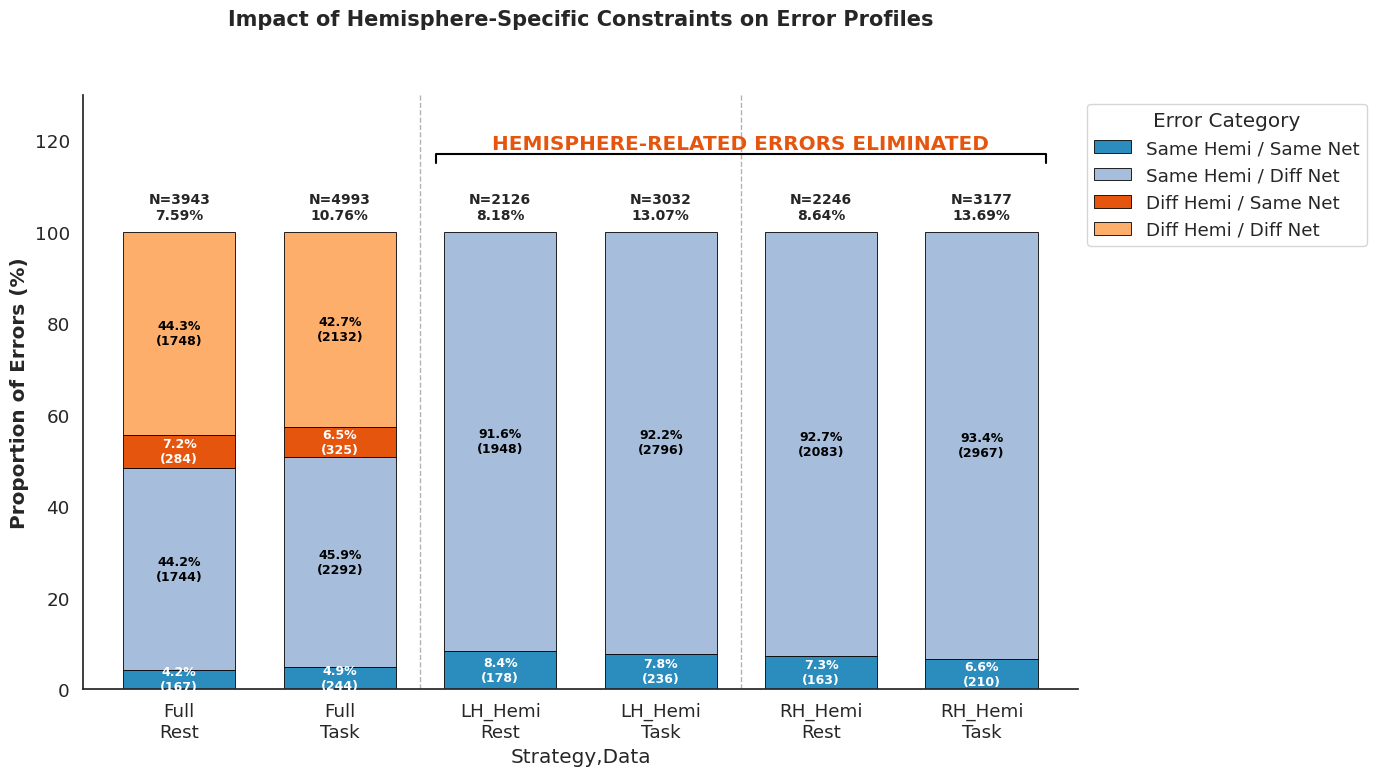

In [19]:
# 1. Clean and Parse Data
df = error_df.copy()
df.columns = ["Strategy", "Data", "N", "Rate", "SH_SN", "SH_DN", "DH_SN", "DH_DN"]

# Extract counts and percentages from strings like "167 (4.2%)"
cols_to_parse = ["SH_SN", "SH_DN", "DH_SN", "DH_DN"]
for col in cols_to_parse:
    df[[f"{col}_count", f"{col}_pct"]] = df[col].str.extract(r'(\d+) \(([\d.]+)%\)').astype(float)

# 2. Setup Plot
sns.set_style("white")
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)

# Colors: Blues (Same Hemi), Oranges (Diff Hemi)
colors = ['#2b8cbe', '#a6bddb', '#e6550d', '#fdae6b']
labels = ["Same Hemi / Same Net", "Same Hemi / Diff Net", "Diff Hemi / Same Net", "Diff Hemi / Diff Net"]

# 3. Plot Stacked Bars
pct_cols = [f"{c}_pct" for c in cols_to_parse]
df_plot = df.set_index(['Strategy', 'Data'])[pct_cols]
df_plot.columns = labels
df_plot.plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.7, edgecolor='black', linewidth=0.6)

# 4. Annotations
for i, (idx, row) in enumerate(df.iterrows()):
    cum_height = 0
    for j, col in enumerate(cols_to_parse):
        pct, count = row[f"{col}_pct"], int(row[f"{col}_count"])
        if pct > 2.0:  # Only label if visible
            ax.text(i, cum_height + (pct/2), f"{pct:.1f}%\n({count})", 
                    ha='center', va='center', color="white" if j in [0, 2] else "black", 
                    fontsize=9, fontweight='bold')
        cum_height += pct
    
    # Header labels (N and Rate)
    ax.text(i, 102, f"N={int(row['N'])}\n{row['Rate']}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# 5. Visual Callouts & Polish
[ax.axvline(x, color='black', ls='--', lw=1, alpha=0.3) for x in [1.5, 3.5]]

# Bracket for Hemisphere-specific models
ax.plot([1.6, 1.6, 5.4, 5.4], [115, 117, 117, 115], color="black", lw=1.5)
ax.text(3.5, 118, "HEMISPHERE-RELATED ERRORS ELIMINATED", ha='center', fontweight='bold', color='#e6550d')

ax.set_ylabel("Proportion of Errors (%)", fontweight='bold')
ax.set_title("Impact of Hemisphere-Specific Constraints on Error Profiles", fontsize=15, pad=50, fontweight='bold')
ax.set_xticklabels([f"{s}\n{d}" for s, d in df_plot.index], rotation=0)
ax.set_ylim(0, 130)
ax.legend(title="Error Category", bbox_to_anchor=(1, 1), loc='upper left')
sns.despine()

plt.tight_layout()
plt.show()

---
## 6. Network-Level Confusion Analysis

Examining which networks are most confused with each other reveals systematic patterns.

In [9]:
def build_network_confusion_matrix(true_labels, pred_labels, region_info_df, use_major=True):
    """Build confusion matrix at the network level."""
    lookup = region_info_df.set_index('region_idx')
    net_col = 'major_network' if use_major else 'network'
    
    true_nets = pd.Series(true_labels).map(lookup[net_col])
    pred_nets = pd.Series(pred_labels).map(lookup[net_col])
    
    networks = sorted(true_nets.unique())
    cm = confusion_matrix(true_nets, pred_nets, labels=networks)
    
    return cm, networks

# Build matrices for rest and task
cm_rest, networks = build_network_confusion_matrix(cv_true_labels_full, cv_predictions_full, region_info_full)
cm_task, _ = build_network_confusion_matrix(task_true_labels_full, task_predictions_full, region_info_full)

# Normalize to show error rates (off-diagonal only)
def normalize_cm_errors(cm):
    """Normalize confusion matrix and zero the diagonal."""
    cm_float = cm.astype(float)
    row_sums = cm_float.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm_float, row_sums, where=row_sums != 0) * 100
    np.fill_diagonal(cm_norm, np.nan)  # Hide correct classifications
    return cm_norm

cm_rest_norm = normalize_cm_errors(cm_rest)
cm_task_norm = normalize_cm_errors(cm_task)

In [20]:

# Networks 
# 1. Networks and Setup
networks = [
    'Visual', 'Somatomotor', 'Dorsal Attention', 'Salience/Ventral Attention',
    'Limbic', 'Control', 'Default', 'Subcortical'
]
rows = ['Full', 'Left', 'Right']
cols = ['Rest (CV)', 'Task (Test)', 'Difference (T-R)']

def aggregate_to_network_sum(region_matrix, region_info):
    net_labels = region_info['major_network'].values
    df = pd.DataFrame(region_matrix, index=net_labels, columns=net_labels)
    
    # Use .sum() to preserve absolute counts
    row_grouped = df.groupby(level=0).sum()
    full_grouped = row_grouped.transpose().groupby(level=0).sum().transpose()
    
    net_matrix = full_grouped.reindex(index=networks, columns=networks).fillna(0)
    return net_matrix.values

# 3. Process matrices for Absolute Counts
full_rest_net = aggregate_to_network_sum(confusion_matrix_cv_full, region_info_full)
full_task_net = aggregate_to_network_sum(confusion_matrix_task_full, region_info_full)
lh_rest_net = aggregate_to_network_sum(confusion_matrix_cv_lh, region_info_lh)
lh_task_net = aggregate_to_network_sum(confusion_matrix_task_lh, region_info_lh)
rh_rest_net = aggregate_to_network_sum(confusion_matrix_cv_rh, region_info_rh)
rh_task_net = aggregate_to_network_sum(confusion_matrix_task_rh, region_info_rh)

# 4. Organize for Plotting
matrix_data = [
    [full_rest_net, full_task_net, (full_task_net - full_rest_net)],
    [lh_rest_net,   lh_task_net,   (lh_task_net - lh_rest_net)],
    [rh_rest_net,   rh_task_net,   (rh_task_net - rh_rest_net)]
]
# 1. Colors from the Bar Chart theme
color_blue = '#2b8cbe'
color_orange = '#e6550d'

# 2. Define Custom Colorscales
colorscale_seq = [[0, '#f7fbff'], [1, color_blue]] 
colorscale_div = [[0, color_blue], [0.5, '#ffffff'], [1, color_orange]]

# 3. Create Heatmap Grid
# Increased vertical/horizontal spacing to prevent label overlap
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[f"<b>{r} Strategy: {c}</b>" for r in rows for c in cols],
    horizontal_spacing=0.12, 
    vertical_spacing=0.15
)

for i in range(3):
    for j in range(3):
        data = matrix_data[i][j].copy()
        mask = np.eye(len(networks), dtype=bool)
        data_masked = np.where(mask, None, data)
        
        if j < 2:
            colorscale = colorscale_seq
            zmin, zmax = 0, np.nanmax(data_masked[data_masked != None])
        else:
            colorscale = colorscale_div
            limit = np.nanmax(np.abs(data_masked[data_masked != None].astype(float)))
            zmin, zmax = -limit, limit

        fig.add_trace(
            go.Heatmap(
                z=data_masked,
                x=networks, 
                y=networks,
                colorscale=colorscale,
                zmin=zmin, 
                zmax=zmax,
                text=data_masked,
                texttemplate="%{text:.0f}",
                textfont={"size": 9},
                showscale=False,
                hovertemplate="True: %{y}<br>Predicted: %{x}<br>Value: %{z}<extra></extra>"
            ),
            row=i+1, col=j+1
        )

# 4. Final Layout Adjustments
fig.update_layout(
    title_text="<b>8-Network Absolute Off-Diagonal Error Counts </b>",
    template="plotly_white",
    height=1300, # Increased height to allow more room for x-labels
    width=1500,
    # Added explicit margins to prevent labels from cutting off at the edges
    margin=dict(l=150, r=50, t=150, b=150)
)

# 5. Prevent Overlap via tickangle and standoff
fig.update_xaxes(
    tickangle=45, 
    tickfont=dict(size=10),
    automargin=True # Automatically adjusts subplot size to fit labels
)

fig.update_yaxes(
    autorange="reversed", 
    tickfont=dict(size=10),
    automargin=True # Ensures network names don't overlap the y-axis
)

fig.show()

---
## 7. Sankey Flow Visualization

Sankey diagrams show the flow of classification errors from true networks through hemispheres to predicted networks.

In [11]:
# Network color mapping (Yeo atlas standard)
NETWORK_COLORS = {
    'Visual': 'rgb(120, 18, 134)',
    'Somatomotor': 'rgb(70, 130, 180)',
    'Dorsal Attention': 'rgb(0, 118, 14)',
    'Salience/Ventral Attention': 'rgb(196, 58, 250)',
    'Limbic': 'rgb(220, 248, 164)',
    'Control': 'rgb(230, 148, 34)',
    'Default': 'rgb(205, 62, 78)',
    'Subcortical': 'rgb(12, 123, 174)'
}

def create_sankey_data(true_labels, pred_labels, region_info_df):
    """Extract error flows for Sankey diagram."""
    err_mask = true_labels != pred_labels
    lookup = region_info_df.set_index('region_idx')
    
    df = pd.DataFrame({
        'true_net': pd.Series(true_labels[err_mask]).map(lookup['major_network']),
        'pred_net': pd.Series(pred_labels[err_mask]).map(lookup['major_network']),
        'true_hemi': pd.Series(true_labels[err_mask]).map(lookup['hemisphere']),
        'pred_hemi': pd.Series(pred_labels[err_mask]).map(lookup['hemisphere'])
    })
    
    return df

def build_sankey_figure(df, title):
    """Build a 4-column Sankey: True Net → True Hemi → Pred Hemi → Pred Net"""
    networks = sorted(df['true_net'].unique())
    
    # Node setup: [8 networks, 2 hemispheres, 2 hemispheres, 8 networks]
    node_labels = networks + ['Left', 'Right'] + ['Left', 'Right'] + networks
    node_colors = [NETWORK_COLORS.get(n, 'gray') for n in networks] + \
                  ['rgb(100,100,100)']*4 + \
                  [NETWORK_COLORS.get(n, 'gray') for n in networks]
    
    # Build links
    sources, targets, values, link_colors = [], [], [], []
    
    # True Net → True Hemi
    for i, net in enumerate(networks):
        for j, hemi in enumerate(['left', 'right']):
            count = len(df[(df['true_net'] == net) & (df['true_hemi'] == hemi)])
            if count > 0:
                sources.append(i)
                targets.append(8 + j)
                values.append(count)
                link_colors.append(NETWORK_COLORS.get(net, 'gray').replace('rgb', 'rgba').replace(')', ',0.4)'))
    
    # True Hemi → Pred Hemi
    for i, th in enumerate(['left', 'right']):
        for j, ph in enumerate(['left', 'right']):
            count = len(df[(df['true_hemi'] == th) & (df['pred_hemi'] == ph)])
            if count > 0:
                sources.append(8 + i)
                targets.append(10 + j)
                values.append(count)
                link_colors.append('rgba(150,150,150,0.3)')
    
    # Pred Hemi → Pred Net
    for i, hemi in enumerate(['left', 'right']):
        for j, net in enumerate(networks):
            count = len(df[(df['pred_hemi'] == hemi) & (df['pred_net'] == net)])
            if count > 0:
                sources.append(10 + i)
                targets.append(12 + j)
                values.append(count)
                link_colors.append(NETWORK_COLORS.get(net, 'gray').replace('rgb', 'rgba').replace(')', ',0.4)'))
    
    fig = go.Figure(go.Sankey(
        node=dict(label=node_labels, color=node_colors, pad=15, thickness=20),
        link=dict(source=sources, target=targets, value=values, color=link_colors)
    ))
    
    fig.update_layout(
        title=title, height=600, width=1000,
        font=dict(size=11),
        annotations=[
            dict(x=0, y=1.08, text='<b>TRUE NETWORK</b>', showarrow=False, xref='paper', yref='paper'),
            dict(x=0.33, y=1.08, text='<b>TRUE HEMI</b>', showarrow=False, xref='paper', yref='paper'),
            dict(x=0.66, y=1.08, text='<b>PRED HEMI</b>', showarrow=False, xref='paper', yref='paper'),
            dict(x=1, y=1.08, text='<b>PRED NETWORK</b>', showarrow=False, xref='paper', yref='paper')
        ]
    )
    return fig

# Generate Sankey for Rest
df_rest = create_sankey_data(cv_true_labels_full, cv_predictions_full, region_info_full)
fig_rest = build_sankey_figure(df_rest, 'Error Flow: Rest (CV) - Full Model')
fig_rest.show()

In [12]:
# Generate Sankey for Task
df_task = create_sankey_data(task_true_labels_full, task_predictions_full, region_info_full)
fig_task = build_sankey_figure(df_task, 'Error Flow: Task - Full Model')
fig_task.show()

print("\n" + "="*80)
print("SANKEY INSIGHT:")
print("Subcortical regions dominate error flows in both conditions.")
print("Cross-hemisphere flows (Left→Right, Right→Left) are substantial.")
print("="*80)


SANKEY INSIGHT:
Subcortical regions dominate error flows in both conditions.
Cross-hemisphere flows (Left→Right, Right→Left) are substantial.


---
## 8. Rest vs Task Error Change Analysis

Examining how error patterns shift from rest to task reveals functional reorganization.

In [13]:
# Calculate network-level error rates
def get_network_error_rates(true_labels, pred_labels, region_info_df):
    """Calculate error rate per network."""
    lookup = region_info_df.set_index('region_idx')
    df = pd.DataFrame({
        'true_net': pd.Series(true_labels).map(lookup['major_network']),
        'correct': true_labels == pred_labels
    })
    
    return df.groupby('true_net').agg(
        total=('correct', 'count'),
        errors=('correct', lambda x: (~x).sum())
    ).assign(error_rate=lambda x: x['errors'] / x['total'])

rest_rates = get_network_error_rates(cv_true_labels_full, cv_predictions_full, region_info_full)
task_rates = get_network_error_rates(task_true_labels_full, task_predictions_full, region_info_full)

# Combine and calculate change
comparison = pd.DataFrame({
    'Network': rest_rates.index,
    'Rest_Error_Rate': rest_rates['error_rate'].values,
    'Task_Error_Rate': task_rates['error_rate'].values
}).assign(
    Change=lambda x: x['Task_Error_Rate'] - x['Rest_Error_Rate'],
    Pct_Change=lambda x: ((x['Task_Error_Rate'] - x['Rest_Error_Rate']) / x['Rest_Error_Rate'] * 100)
).sort_values('Change', ascending=False)

print("="*80)
print("NETWORK ERROR RATE CHANGE: Rest → Task")
print("="*80)
print(comparison.to_string(index=False))
print("\nPositive change = more errors during task")

NETWORK ERROR RATE CHANGE: Rest → Task
                   Network  Rest_Error_Rate  Task_Error_Rate    Change  Pct_Change
               Subcortical         0.169364         0.257812  0.088449   52.224053
Salience/Ventral Attention         0.068338         0.100385  0.032047   46.894472
               Somatomotor         0.042411         0.071324  0.028913   68.173375
                   Control         0.057070         0.082027  0.024957   43.729387
                    Visual         0.030878         0.055208  0.024330   78.795181
                   Default         0.065199         0.087442  0.022243   34.114650
                    Limbic         0.140944         0.159643  0.018699   13.266968
          Dorsal Attention         0.060674         0.060227 -0.000446   -0.735786

Positive change = more errors during task


In [ ]:
# Visualize error rate changes
fig = go.Figure()

# Add lines connecting rest to task
for _, row in comparison.iterrows():
    color = NETWORK_COLORS.get(row['Network'], 'gray')
    fig.add_trace(go.Scatter(
        x=['Rest (CV)', 'Task'],
        y=[row['Rest_Error_Rate'], row['Task_Error_Rate']],
        mode='lines+markers',
        name=row['Network'],
        line=dict(color=color, width=2.5),
        marker=dict(size=10)
    ))

fig.update_layout(
    title='Network Error Rates: Rest vs Task',
    xaxis_title='Condition',
    yaxis_title='Error Rate',
    height=500, width=800,
    template='plotly_white',
    legend=dict(x=1.02, y=0.5)
)

fig.show()

print("\n" + "="*80)
print("TASK-INDUCED CHANGES:")
print("Subcortical shows largest absolute increase in errors.")
print("Visual and Somatomotor networks also show increased errors during task.")
print("="*80)


TASK-INDUCED CHANGES:
Subcortical shows largest absolute increase in errors.
Visual and Somatomotor networks also show increased errors during task.


---
## 9. Regional Error Analysis

Drilling down to individual regions to identify the most problematic classifications.

In [15]:
# Calculate per-region error counts
def get_region_errors(true_labels, pred_labels, region_info_df):
    """Get error counts per region."""
    errors = pd.Series(true_labels[true_labels != pred_labels]).value_counts()
    total = pd.Series(true_labels).value_counts()
    
    result = region_info_df.copy()
    result['errors'] = result['region_idx'].map(errors).fillna(0).astype(int)
    result['total'] = result['region_idx'].map(total).fillna(0).astype(int)
    result['error_rate'] = result['errors'] / result['total']
    
    return result

rest_regions = get_region_errors(cv_true_labels_full, cv_predictions_full, region_info_full)
task_regions = get_region_errors(task_true_labels_full, task_predictions_full, region_info_full)

# Merge for comparison
region_comparison = rest_regions[['region_name', 'major_network', 'hemisphere', 'errors', 'error_rate']].rename(
    columns={'errors': 'rest_errors', 'error_rate': 'rest_rate'}
).merge(
    task_regions[['region_name', 'errors', 'error_rate']].rename(
        columns={'errors': 'task_errors', 'error_rate': 'task_rate'}
    ), on='region_name'
).assign(
    error_change=lambda x: x['task_errors'] - x['rest_errors'],
    rate_change=lambda x: x['task_rate'] - x['rest_rate']
)

# Show top error-increasing regions
print("="*80)
print("TOP 15 REGIONS WITH LARGEST ERROR INCREASE (Rest → Task)")
print("="*80)
print(region_comparison.nlargest(15, 'error_change')[[
    'region_name', 'major_network', 'hemisphere', 'rest_errors', 'task_errors', 'error_change'
]].to_string(index=False))

TOP 15 REGIONS WITH LARGEST ERROR INCREASE (Rest → Task)
          region_name              major_network hemisphere  rest_errors  task_errors  error_change
RH_SalVentAttnA_PrC_1 Salience/Ventral Attention      right           38           83            45
               aGP-lh                Subcortical       left          110          152            42
               aGP-rh                Subcortical      right          108          147            39
      RH_ContA_PFCl_1                    Control      right           14           49            35
     LH_ContA_Cingm_1                    Control       left           18           48            30
            THA-VP-rh                Subcortical      right           34           64            30
     RH_ContA_Cingm_1                    Control      right           14           41            27
              pHIP-rh                Subcortical      right           37           64            27
              pPUT-lh                Subcor

In [30]:
import plotly.express as px

# 1. Prepare Data
df_plot = region_comparison.melt(
    id_vars=['region_name', 'major_network'], 
    value_vars=['rest_rate', 'task_rate'],
    var_name='Condition', value_name='Error Rate'
).replace({'rest_rate': 'Resting State', 'task_rate': 'Task-Based'})

# 2. Generate Figure
fig = px.violin(
    df_plot,
    x='major_network', 
    y='Error Rate', 
    color='Condition',
    box=True, 
    points='all', # "all" is good for transparency, "outliers" is cleaner for large N
    category_orders={"Condition": ["Resting State", "Task-Based"]},
    color_discrete_map={'Resting State': '#1f77b4', 'Task-Based': '#ff7f0e'}
)

# 3. Academic Styling
fig.update_layout(
    template='simple_white', # Cleaner than plotly_white for journals
    height=600, 
    width=1000,
    font=dict(family="Arial", size=14, color="black"),
    title={
        'text': "<b>Figure 1.</b> Regional Error Rate Distribution Across Major Networks",
        'y':0.95, 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    legend=dict(
        title="", # Removed for cleaner look
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    margin=dict(l=60, r=40, t=100, b=100)
)

# 4. Axis Refinement
fig.update_xaxes(
    title_text="<b>Major Network</b>", 
    tickangle=45,
    showline=True, 
    linewidth=1.5, 
    linecolor='black'
)

fig.update_yaxes(
    title_text="<b>Error Rate (%)</b>", 
    showgrid=True, 
    gridcolor='lightgrey',
    showline=True, 
    linewidth=1.5, 
    linecolor='black'
)

# 5. Violin Adjustments
fig.update_traces(
    meanline_visible=True,
    scalemode='width', # Ensures violins are comparable across networks
    marker=dict(size=3, opacity=0.5) # Smaller points prevent cluttering
)

fig.show()

---
## 10. Anatomical Hub Analysis

Visualizing error patterns across the anatomical axis to identify spatial clustering.

In [23]:
# Prepare data structures
matrices_dict = {
    'full_rest': confusion_matrix_cv_full,
    'full_task': confusion_matrix_task_full,
    'lh_rest': confusion_matrix_cv_lh,
    'lh_task': confusion_matrix_task_lh,
    'rh_rest': confusion_matrix_cv_rh,
    'rh_task': confusion_matrix_task_rh
}

infos_dict = {
    'full': region_info_full,
    'lh': region_info_lh,
    'rh': region_info_rh
}

def plot_anatomical_errors(matrices, region_infos):
    """Create 9-subplot anatomical error analysis."""
    fig = make_subplots(
        rows=3, cols=3,
        subplot_titles=(
            "Full: Rest", "LH: Rest", "RH: Rest",
            "Full: Task", "LH: Task", "RH: Task",
            "Full: Δ (Task-Rest)", "LH: Δ (Task-Rest)", "RH: Δ (Task-Rest)"
        ),
        horizontal_spacing=0.07,
        vertical_spacing=0.1
    )

    strategies = [('full', 'Full Brain'), ('lh', 'Left Hemisphere'), ('rh', 'Right Hemisphere')]
    networks = sorted(region_infos['full']['major_network'].unique())
    colors = px.colors.qualitative.Safe
    color_map = {net: colors[i % len(colors)] for i, net in enumerate(networks)}

    # Calculate global scales
    max_abs, max_diff = 0, 0
    for model_key, _ in strategies:
        r_cm = matrices[f'{model_key}_rest'].astype(float).copy()
        t_cm = matrices[f'{model_key}_task'].astype(float).copy()
        np.fill_diagonal(r_cm, 0)
        np.fill_diagonal(t_cm, 0)
        max_abs = max(max_abs, r_cm.sum(axis=1).max(), t_cm.sum(axis=1).max())
        max_diff = max(max_diff, (t_cm.sum(axis=1) - r_cm.sum(axis=1)).max())

    # Populate grid
    for col_idx, (model_key, _) in enumerate(strategies, start=1):
        info = region_infos[model_key]
        r_cm = matrices[f'{model_key}_rest'].astype(float).copy()
        t_cm = matrices[f'{model_key}_task'].astype(float).copy()
        np.fill_diagonal(r_cm, 0)
        np.fill_diagonal(t_cm, 0)
        
        r_err = r_cm.sum(axis=1)
        t_err = t_cm.sum(axis=1)
        d_err = t_err - r_err

        for err_vals, row_idx, scale_ref in [(r_err, 1, max_abs), (t_err, 2, max_abs), (d_err, 3, max_diff)]:
            df_plot = pd.DataFrame({
                'Region': info['region_name'],
                'Network': info['major_network'],
                'Error_Count': err_vals,
                'X_Pos': np.arange(len(info))
            })

            for net in networks:
                net_df = df_plot[df_plot['Network'] == net]
                if net_df.empty:
                    continue
                
                fig.add_trace(
                    go.Scatter(
                        x=net_df['X_Pos'],
                        y=net_df['Error_Count'],
                        mode='markers',
                        name=net,
                        marker=dict(
                            size=np.abs(net_df['Error_Count']),
                            sizemode='area',
                            sizeref=2. * scale_ref / (30.**2),
                            sizemin=2,
                            color=color_map[net],
                            line=dict(width=0.4, color='white')
                        ),
                        text=net_df['Region'],
                        hovertemplate="<b>%{text}</b><br>Errors: %{y}<extra></extra>",
                        legendgroup=net,
                        showlegend=(row_idx == 1 and col_idx == 1)
                    ),
                    row=row_idx, col=col_idx
                )

    fig.update_layout(
        title='Anatomical Error Distribution: Model × Condition Comparison',
        height=1200, width=1600,
        template='plotly_white',
        legend=dict(title='Network', orientation='h', y=-0.05, x=0.5, xanchor='center')
    )
    
    fig.update_xaxes(showticklabels=False, title='Anatomical Axis')
    fig.update_yaxes(title_text='Abs. Errors', row=1, col=1)
    fig.update_yaxes(title_text='Abs. Errors', row=2, col=1)
    fig.update_yaxes(title_text='Δ Errors', row=3, col=1)
    
    return fig

fig_hubs = plot_anatomical_errors(matrices_dict, infos_dict)
fig_hubs.show()

---
## 11. Limitations Summary & Motivation for OvR/OvO

### Key Findings from Multinomial Error Analysis

1. **Joint Classification Problem**: The multinomial model treats the 232-class problem as a single flat classification, ignoring the inherent structure (hemisphere × network × sub-region).

2. **High "Both Wrong" Error Rate**: ~44% of errors involve confusion in BOTH hemisphere AND network, suggesting the model cannot effectively separate these orthogonal dimensions.

3. **Subcortical Dominance**: Subcortical regions consistently show the highest error rates and error increases during task, overwhelming the more structured cortical classifications.

4. **Task Transfer Gap**: Consistent ~10% accuracy drop from rest to task indicates the multinomial captures state-specific rather than generalizable connectivity patterns.

### Why OvR and OvO?

**One-vs-Rest (OvR)**:
- Decomposes the 232-class problem into 232 binary classifiers
- Each classifier focuses on distinguishing one region from all others
- Better handles class imbalance inherent in regional connectivity
- Allows per-region threshold optimization

**One-vs-One (OvO)**:
- Creates K(K-1)/2 = 26,796 pairwise classifiers for 232 classes
- Each classifier only sees relevant pair of regions
- Can capture fine-grained differences between similar regions
- Voting mechanism provides confidence estimates

### Expected Improvements:
- Better separation of hemisphere vs. network errors
- Improved handling of subcortical regions
- More interpretable error patterns
- Potentially better task transfer through more robust decision boundaries

In [18]:
# Summary statistics
print("="*80)
print("MULTINOMIAL CLASSIFICATION SUMMARY")
print("="*80)
print(f"\nFull Model (232 regions):")
print(f"  CV Accuracy:     {overall_metrics_full['accuracy']:.2%}")
print(f"  Task Accuracy:   {task_summary_full['task_test_accuracy']:.2%}")
print(f"  Transfer Gap:    {task_summary_full['accuracy_drop']:.2%}")
print(f"\nError Composition (Task):")
print(f"  Both Wrong:      ~44% of errors")
print(f"  Network Only:    ~46% of errors")
print(f"  Hemisphere Only: ~7% of errors")
print(f"\nHighest Error Networks:")
print(f"  1. Subcortical")
print(f"  2. Limbic")
print(f"  3. Salience/Ventral Attention")
print("\n" + "="*80)
print("NEXT STEPS: Implement OvR and OvO classifiers to address these limitations.")
print("="*80)

MULTINOMIAL CLASSIFICATION SUMMARY

Full Model (232 regions):
  CV Accuracy:     92.41%
  Task Accuracy:   89.24%
  Transfer Gap:    9.78%

Error Composition (Task):
  Both Wrong:      ~44% of errors
  Network Only:    ~46% of errors
  Hemisphere Only: ~7% of errors

Highest Error Networks:
  1. Subcortical
  2. Limbic
  3. Salience/Ventral Attention

NEXT STEPS: Implement OvR and OvO classifiers to address these limitations.
